In [6]:
import random
import math
import matplotlib.pyplot as plt

def simulate_soft_stack(N, epsilon, target_t_i, num_trials=10000):
    """
    Simulates the soft stack to find the empirical probability that the
    element pushed at time t_i is successfully retrieved at the correct decode time.
    """
    success_count = 0
    
    for _ in range(num_trials):
        stack = []
        
        # push with prob (1-epsilon), pop with prob epsilon 
        for t in range(1, N + 1):
            if random.random() < (1 - epsilon): 
                stack.append(t)
            else: 
                if stack:
                    stack.pop()
                    
        # Pop with prob (1-epsilon), push with prob epsilon 
        outputs = []
        for t in range(1, N + 1):
            if random.random() < (1 - epsilon): 
                if stack:
                    outputs.append(stack.pop())
                else:
                    outputs.append(None) # Stack empty
            else: 
                stack.append(-1) # push of noise
                outputs.append(None) # No element popped 
        
        decode_index = N - target_t_i
        
        if decode_index < len(outputs) and outputs[decode_index] == target_t_i:
            success_count += 1
            
    return success_count / num_trials


In [7]:
N = 50           
epsilon = 0.01          
num_trials = 50000     

empirical_probs = []
theoretical_bounds = []

n_values = list(range(1, N)) 

for n in n_values:
    t_i = N - n
    
    emp_p = simulate_soft_stack(N, epsilon, t_i, num_trials)
    empirical_probs.append(emp_p)
    
    # theoretical bound from proof
    theo_p = 1.0 / math.sqrt(2 * math.pi * n * epsilon * (1 - epsilon))
    theoretical_bounds.append(theo_p)

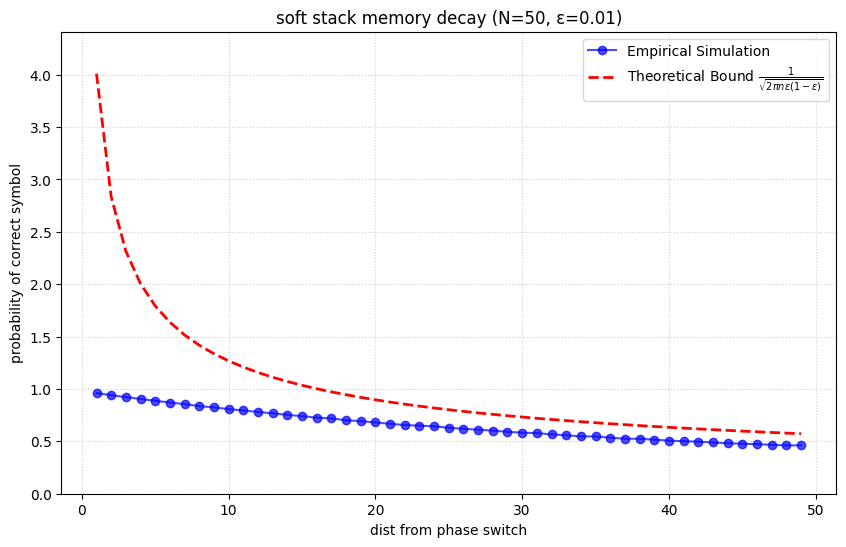

In [8]:

plt.figure(figsize=(10, 6))
plt.plot(n_values, empirical_probs, 'bo-', alpha=0.7, label='Empirical Simulation')
plt.plot(n_values, theoretical_bounds, 'r--', linewidth=2, label=r'Theoretical Bound $\frac{1}{\sqrt{2\pi n \epsilon (1-\epsilon)}}$')

plt.xlabel('dist from phase switch')
plt.ylabel('probability of correct symbol')
plt.title(f'soft stack memory decay (N={N}, ε={epsilon})')
plt.ylim(0, max(theoretical_bounds) * 1.1)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

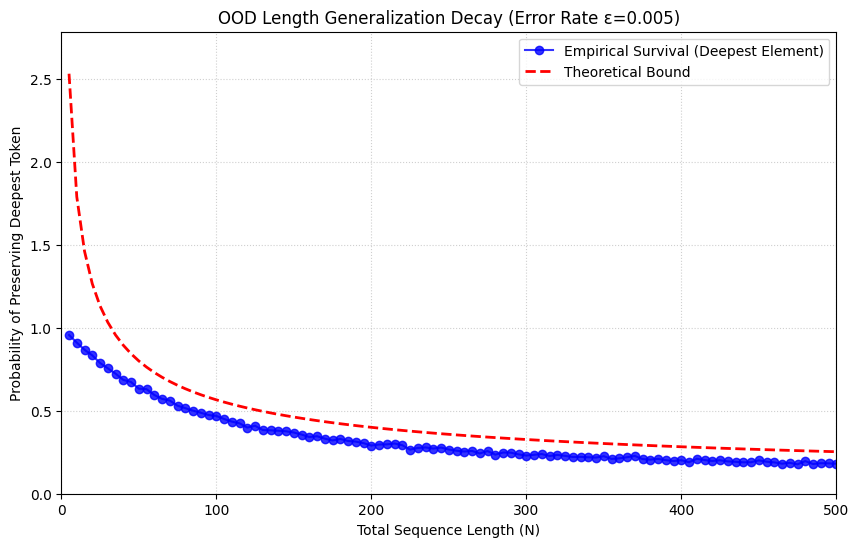

In [29]:
import random
import math
import matplotlib.pyplot as plt

def simulate_deepest_element(N, epsilon, num_trials=5000):
    """
    Simulates the stack for a sequence of length N to find the empirical 
    probability that the FIRST element pushed (t=1) is successfully 
    retrieved at the very last step (t=2N).
    """
    success_count = 0
    
    for _ in range(num_trials):
        stack = []
        
    
        for t in range(1, N + 1):
            if random.random() < (1 - epsilon): 
                stack.append(t)
            else: 
                if stack:
                    stack.pop()
                    
        # Phase 2: Decoding (Popping N elements)
        outputs = []
        for t in range(1, N + 1):
            if random.random() < (1 - epsilon): 
                outputs.append(stack.pop() if stack else None)
            else: 
                stack.append(-1) # Erroneous push
                outputs.append(None)
        
        # Perfect retrieval check: The first element pushed (1) 
        # must be the last element popped (index N-1)
        if len(outputs) == N and outputs[-1] == 1:
            success_count += 1
            
    return success_count / num_trials

# --- OOD Simulation Parameters ---
# We train up to N=40, but evaluate length generalization up to N=120
N_train_max = 80     
N_eval_max = 500      
epsilon = 0.005       # Fixed error rate learned by the controller

n_values = list(range(5, N_eval_max + 1, 5)) # Step by 5 to speed up simulation
empirical_probs = []
theoretical_bounds = []

for N in n_values:
    # 1. Compute Empirical Probability for the deepest element
    emp_p = simulate_deepest_element(N, epsilon, num_trials=5000)
    empirical_probs.append(emp_p)
    
    # 2. Compute Theoretical Bound
    # For the deepest element, the distance to the phase switch is exactly N.
    theo_p = 1.0 / math.sqrt(2 * math.pi * N * epsilon * (1 - epsilon))
    theoretical_bounds.append(theo_p)

# --- Visualization ---
plt.figure(figsize=(10, 6))

# Plot empirical data and theoretical bound
plt.plot(n_values, empirical_probs, 'bo-', alpha=0.8, label='Empirical Survival (Deepest Element)')
plt.plot(n_values, theoretical_bounds, 'r--', linewidth=2, label=r'Theoretical Bound')



# Formatting
plt.xlabel('Total Sequence Length (N)')
plt.ylabel('Probability of Preserving Deepest Token')
plt.title(f'OOD Length Generalization Decay (Error Rate ε={epsilon})')
plt.ylim(0, max(theoretical_bounds) * 1.1)
plt.xlim(0, N_eval_max)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

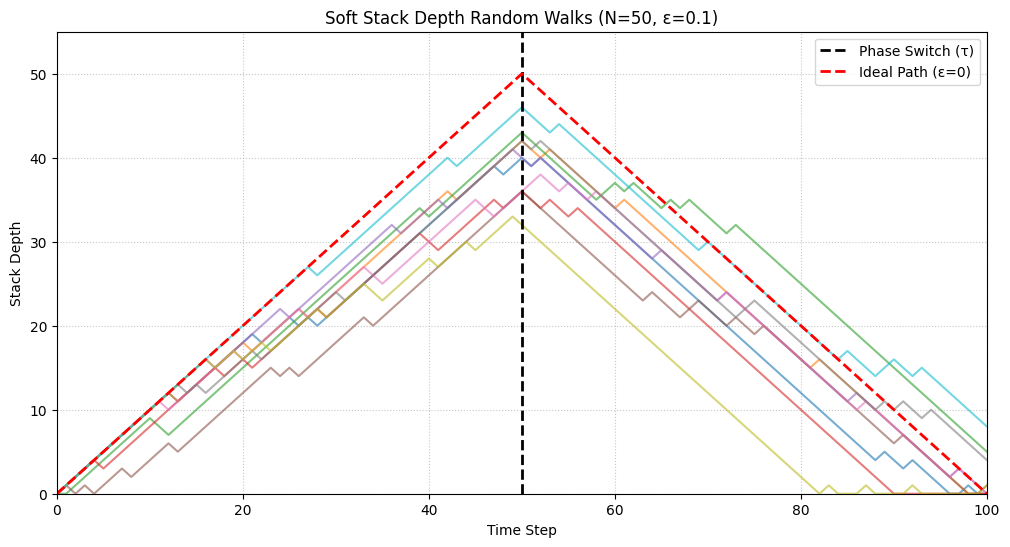

In [10]:
import random
import matplotlib.pyplot as plt

def generate_random_walk(N, epsilon):
    """
    Generates a single random walk representing stack depth over 2N steps.
    """
    depths = [0]
    current_depth = 0
    
    for _ in range(N):
        if random.random() < (1 - epsilon):
            current_depth += 1  
        else:
            current_depth = max(0, current_depth - 1) 
        depths.append(current_depth)
        
    for _ in range(N):
        if random.random() < (1 - epsilon):
            current_depth = max(0, current_depth - 1)  
        else:
            current_depth += 1  
        depths.append(current_depth)
        
    return depths

N = 50           
epsilon = 0.10   
num_paths = 10   

plt.figure(figsize=(12, 6))

for i in range(num_paths):
    walk = generate_random_walk(N, epsilon)
    plt.plot(range(2 * N + 1), walk, alpha=0.6, linewidth=1.5)

plt.axvline(x=N, color='black', linestyle='--', linewidth=2, label='Phase Switch (τ)')
#plt.axvspan(0, N, alpha=0.1, color='gray', label='Encoding Phase')
#plt.axvspan(N, 2 * N, alpha=0.05, color='black', label='Decoding Phase')

ideal_path = list(range(N + 1)) + list(range(N - 1, -1, -1))
plt.plot(range(2 * N + 1), ideal_path, 'r--', linewidth=2, label='Ideal Path (ε=0)')

plt.title(f'Soft Stack Depth Random Walks (N={N}, ε={epsilon})')
plt.xlabel('Time Step')
plt.ylabel('Stack Depth')
plt.xlim(0, 2 * N)
plt.ylim(0, N * 1.1)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

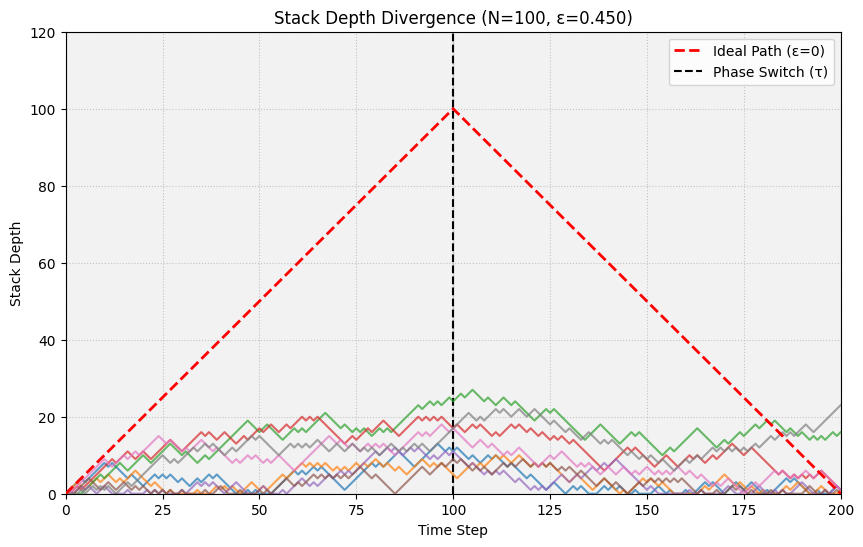

In [11]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def generate_random_walk(N, epsilon):
    depths = [0]
    current_depth = 0
    for _ in range(N):
        current_depth = current_depth + 1 if random.random() < (1 - epsilon) else max(0, current_depth - 1)
        depths.append(current_depth)
    for _ in range(N):
        current_depth = max(0, current_depth - 1) if random.random() < (1 - epsilon) else current_depth + 1
        depths.append(current_depth)
    return depths

N = 100
num_paths = 8
frames = 60
epsilons = np.linspace(0.0, 0.45, frames) 

fig, ax = plt.subplots(figsize=(10, 6))

ideal_path = list(range(N + 1)) + list(range(N - 1, -1, -1))
ax.plot(range(2 * N + 1), ideal_path, 'r--', linewidth=2, zorder=10, label='Ideal Path (ε=0)')
ax.axvline(x=N, color='black', linestyle='--', linewidth=1.5, label='Phase Switch (τ)')
ax.axvspan(0, N, alpha=0.1, color='gray')
ax.axvspan(N, 2 * N, alpha=0.05, color='black')

ax.set_xlim(0, 2 * N)
ax.set_ylim(0, N * 1.2)
ax.set_xlabel('Time Step')
ax.set_ylabel('Stack Depth')
ax.legend(loc='upper right')
ax.grid(True, linestyle=':', alpha=0.7)

lines = [ax.plot([], [], alpha=0.7, linewidth=1.5)[0] for _ in range(num_paths)]
title = ax.set_title('')

def init():
    for line in lines:
        line.set_data([], [])
    title.set_text('')
    return lines + [title]

def update(frame):
    current_epsilon = epsilons[frame]
    title.set_text(f'Stack Depth Divergence (N={N}, ε={current_epsilon:.3f})')
    
    for line in lines:
        walk = generate_random_walk(N, current_epsilon)
        line.set_data(range(2 * N + 1), walk)
        
    return lines + [title]

ani = animation.FuncAnimation(fig, update, frames=frames, init_func=init, blit=True)
ani.save('stack_divergence.gif', writer='pillow', fps=3)


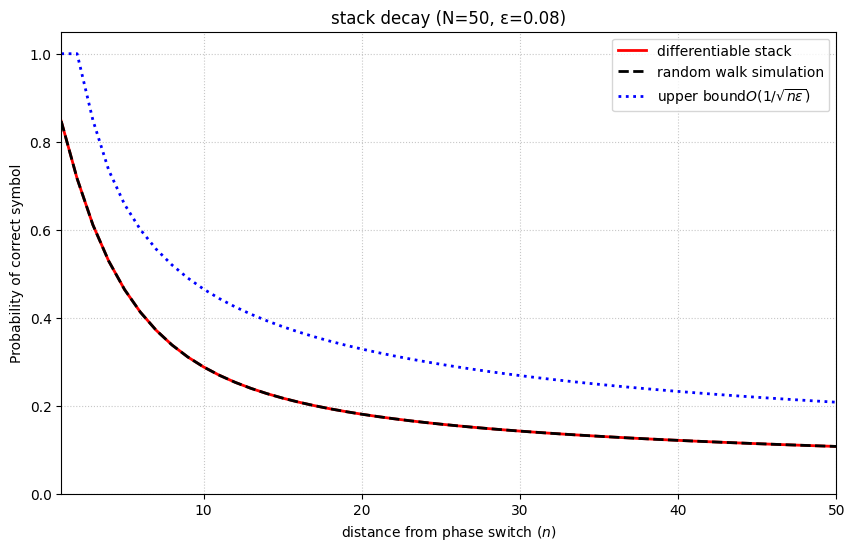

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_true_differentiable_stack(N, epsilon):
    """
    Simulate a true StackRNN stack
    """
    max_depth = 2 * N + 5
    
    # [depth_k, vocab_size]
    #
    S = np.zeros((max_depth, N + 1))
    
    output_probs = np.zeros(N)
    
    for t in range(1, N + 1):
        v_push = 1 - epsilon
        v_pop = epsilon
        
        new_S = np.zeros_like(S)
        
        new_vec = np.zeros(N + 1)
        new_vec[t] = 1.0
        
        #Depth 0 
        new_S[0] = v_push * new_vec + v_pop * S[1]
        
        # shift rest of stack
        for k in range(1, max_depth - 1):
            new_S[k] = v_push * S[k-1] + v_pop * S[k+1]
            
        S = new_S

    for d in range(N):
        target_token = N - d
        
        seen_token = N if d == 0 else N - d + 1

        v_push = epsilon
        v_pop = 1 - epsilon
        
        new_S = np.zeros_like(S)
        
        erroneous_vec = np.zeros(N + 1)
        erroneous_vec[seen_token] = 1.0
        

        readout_vector = v_pop * S[0]
        
        # Shift operator
        new_S[0] = v_push * erroneous_vec + v_pop * S[1]
        for k in range(1, max_depth - 1):
            new_S[k] = v_push * S[k-1] + v_pop * S[k+1]
            
        S = new_S
        

        output_probs[d] = readout_vector[target_token]

    return output_probs

def exact_markov_diffusion(N, epsilon):
    """The analytical expected probability from the random walk proof."""
    probs = np.zeros(N)
    for d in range(N):
        n = d 
        max_depth = 2 * N + 5
        P = np.zeros(max_depth)
        P[1] = 1 - epsilon 
        
        for _ in range(n):
            new_P = np.zeros(max_depth)
            for k in range(1, max_depth - 1):
                new_P[k+1] += P[k] * (1 - epsilon)
                new_P[k-1] += P[k] * epsilon       
            P = new_P
            
        for _ in range(n):
            new_P = np.zeros(max_depth)
            for k in range(1, max_depth - 1):
                new_P[k+1] += P[k] * epsilon       
                new_P[k-1] += P[k] * (1 - epsilon) 
            P = new_P
            
        probs[d] = P[1] * (1 - epsilon)
    return probs


N = 50
epsilon = 0.08
decode_timesteps = np.arange(1, N + 1)

soft_stack_probs = simulate_true_differentiable_stack(N, epsilon)
markov_probs = exact_markov_diffusion(N, epsilon)
theoretical_bounds = np.clip(1.0 / np.sqrt(2 * np.pi * decode_timesteps * epsilon * (1 - epsilon)), 0, 1)

plt.figure(figsize=(10, 6))

plt.plot(decode_timesteps, soft_stack_probs, 'r-', linewidth=2,
         label='differentiable stack')

plt.plot(decode_timesteps, markov_probs, 'k--', linewidth=2, 
         label='random walk simulation')

plt.plot(decode_timesteps, theoretical_bounds, 'b:', linewidth=2, 
         label=r'upper bound$O(1/\sqrt{n\epsilon})$')

plt.title(f'stack decay (N={N}, ε={epsilon})')
plt.xlabel('distance from phase switch ($n$)')
plt.ylabel('Probability of correct symbol')
plt.ylim(0, 1.05)
plt.xlim(1, N)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

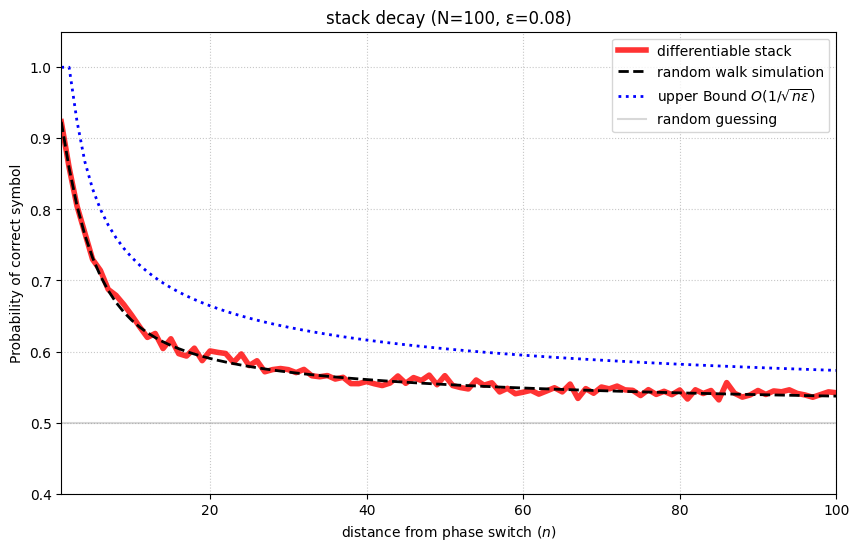

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_binary_differentiable_stack(N, epsilon, num_trials=500):
    max_depth = 2 * N + 5
    output_probs = np.zeros(N)
    
    for _ in range(num_trials):
        S = np.zeros((max_depth, 2))
        X = np.random.randint(0, 2, N)
        
        for t in range(N):
            v_push = 1 - epsilon
            v_pop = epsilon
            
            new_S = np.zeros_like(S)
            new_vec = np.zeros(2)
            new_vec[X[t]] = 1.0
            
            new_S[0] = v_push * new_vec + v_pop * S[1]
            for k in range(1, max_depth - 1):
                new_S[k] = v_push * S[k-1] + v_pop * S[k+1]
            S = new_S

        for d in range(N):
            target_token = X[N - 1 - d]
            seen_token = X[N - 1] if d == 0 else X[N - d]
            
            v_push = epsilon
            v_pop = 1 - epsilon
            
            new_S = np.zeros_like(S)
            erroneous_vec = np.zeros(2)
            erroneous_vec[seen_token] = 1.0
            
            readout_vector = v_pop * S[0]
            
            new_S[0] = v_push * erroneous_vec + v_pop * S[1]
            for k in range(1, max_depth - 1):
                new_S[k] = v_push * S[k-1] + v_pop * S[k+1]
            S = new_S
            
            total_readout_mass = np.sum(readout_vector)
            prob_correct = readout_vector[target_token] + 0.5 * (1.0 - total_readout_mass)
            
            output_probs[d] += prob_correct

    return output_probs / num_trials

def exact_markov_diffusion(N, epsilon):
    probs = np.zeros(N)
    for d in range(N):
        n = d 
        max_depth = 2 * N + 5
        P = np.zeros(max_depth)
        P[1] = 1 - epsilon 
        
        for _ in range(n):
            new_P = np.zeros(max_depth)
            for k in range(1, max_depth - 1):
                new_P[k+1] += P[k] * (1 - epsilon)
                new_P[k-1] += P[k] * epsilon       
            P = new_P
            
        for _ in range(n):
            new_P = np.zeros(max_depth)
            for k in range(1, max_depth - 1):
                new_P[k+1] += P[k] * epsilon       
                new_P[k-1] += P[k] * (1 - epsilon) 
            P = new_P
            
        probs[d] = P[1] * (1 - epsilon)
    return probs

N = 100
epsilon = 0.08
decode_timesteps = np.arange(1, N + 1)

fidelity_probs = exact_markov_diffusion(N, epsilon)
binary_markov_probs = 0.5 + 0.5 * fidelity_probs

binary_soft_stack_probs = simulate_binary_differentiable_stack(N, epsilon, num_trials=500)

raw_theoretical_bounds = np.clip(1.0 / np.sqrt(2 * np.pi * decode_timesteps * epsilon * (1 - epsilon)), 0, 1)
binary_theoretical_bounds = 0.5 + 0.5 * raw_theoretical_bounds

plt.figure(figsize=(10, 6))

plt.plot(decode_timesteps, binary_soft_stack_probs, 'r-', linewidth=4, alpha=0.8,
         label='differentiable stack')

plt.plot(decode_timesteps, binary_markov_probs, 'k--', linewidth=2, 
         label='random walk simulation')

plt.plot(decode_timesteps, binary_theoretical_bounds, 'b:', linewidth=2, 
         label=r'upper Bound $O(1/\sqrt{n\epsilon})$')

plt.title(f'stack decay (N={N}, ε={epsilon})')
plt.xlabel('distance from phase switch ($n$)')
plt.ylabel('Probability of correct symbol')
plt.ylim(0.4, 1.05)
plt.xlim(1, N)
plt.axhline(y=0.5, color='gray', linestyle='-', alpha=0.3, label='random guessing')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()
